# Primacy to target neuron

### (From the output of the inputs of the target neuron)

For a **target** neuron (or group), find where the target ranks among each of its inputs' own outputs. Rank 0 = primary, rank 1 = secondary, etc.

This mirrors the `primacy` loop in Dr. Gutierrez's *Hub Bespoke Figures* notebook (cell 11), with flexibility added for:
- Different data sources (Neuprint, FlyWire, BANC, ...)
- Single-neuron vs cell-type resolution on both sides
- Single target or group of targets

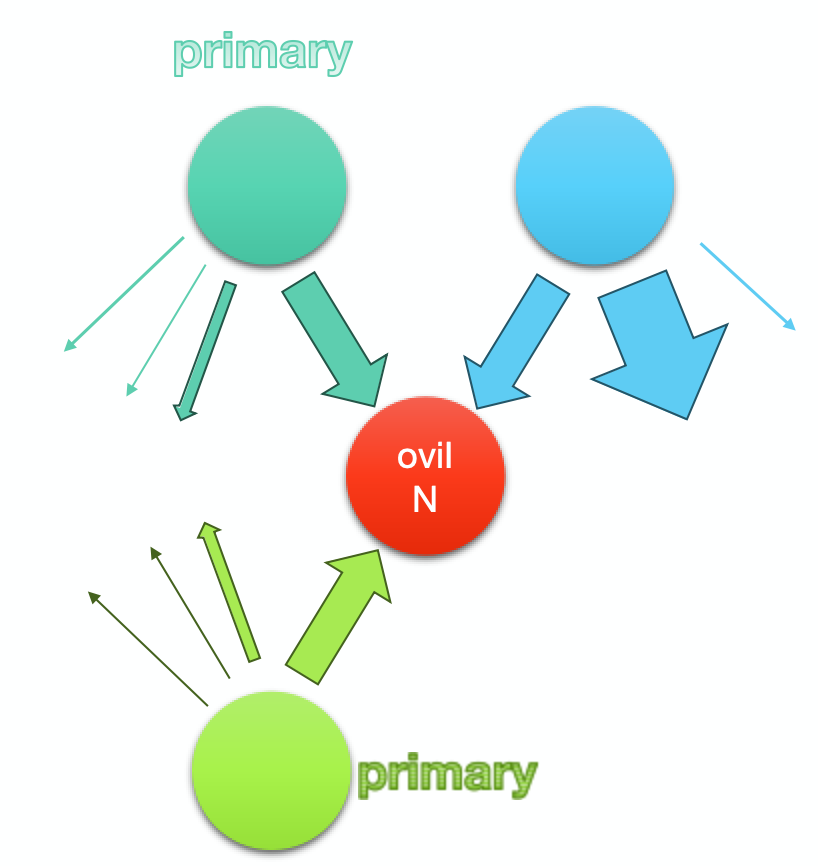

## Overview

For each input `S` to target `T`, rank `T` among `S`'s downstream partners. Primary (rank 0) = `T` is `S`'s strongest output; higher ranks = `T` is a weaker destination for `S`.

Steps:
1. Fetch inputs to target
2. Collapse to chosen pre-side resolution (neuron or cell type)
3. For each source, fetch its outputs and find the target's rank
4. Assemble the primacy dataframe
5. Package as `compute_primacy()` + standalone `.py`

Sanity checks run inline between steps.


# What this notebook does:

This notebook takes the primacy loop from cell 11 of the Hub Bespoke notebook and rebuilds it as a modular, dataset-agnostic pipeline. The scientific question is the same: for a target neuron (e.g. oviIN), each of its inputs is examined to determine where the target ranks among that input's own downstream partners. Rank 0 means the target is the input's strongest output (primary connection), rank 1 means secondary, and so on. Tied partners share the same rank, leaving post-hoc tie-breaking to the user.

## What changed from the original:

The pipeline has no knowledge of Neuprint or any specific dataset. Two fetch functions are supplied by the user — one for "get inputs to target" and one for "get outputs from source." For Neuprint, these are one-line wrappers around fetch_simple_connections. For FlyWire or BANC, they would be pandas filters on CSVs. The rest of the pipeline runs identically either way.

Flexibility was added on four axes: the target can be a single neuron, a cell type, or a list of either. The presynaptic side can be analyzed per-neuron or per-cell-type, independently from the target side. When the target is multiple neurons, the default at neuron level keeps them separate (one primacy row per source-target pair), but this can be overridden to combine weights as the original notebook does at type level.

## Notebook structure:

The logic is walked through step-by-step — fetch inputs, collapse to the chosen resolution, demonstrate ranking on one example source, then loop over all sources. Eight inline sanity checks run between steps, catching duplicate edges, schema mismatches, pre/post swaps in custom fetch functions, and ignored weight thresholds. At the end, everything is packaged into compute_primacy(), verified against the manual walkthrough, and then called from the standalone primacy_pipeline.py script.

## Design decisions:

1. Default is single-neuron level — weights are not combined across target members unless explicitly requested.
2. Tied partners share a rank (rank(method='min')).
3. No default quality filters — the caller controls all filtering.
4. An inner weight threshold of 3 applies only when grouping by cell type (single-synapse noise can shift type-level ranks).
5. Self-loops are left in for type mode and are naturally absent for neuron mode.


In [1]:
# Imports
import numpy as np
import pandas as pd


In [2]:
# Optional: silence pandas groupby warnings
import warnings
warnings.filterwarnings('ignore')


In [3]:
!pip install neuprint-python

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.7/109.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.9 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=722966d5b3f6d29747d5da52e5b838563583faa4c91bafa29fc4091724754965
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [4]:
import os
from google.colab import userdata
from neuprint import Client, fetch_simple_connections
auth_token = userdata.get('NEUPRINT_TOKEN')
c = Client('neuprint.janelia.org', dataset='hemibrain:v1.2.1', token=auth_token)
c.fetch_version()

# In the local environment use this version
# from neuprint import Client, fetch_simple_connections

# c = Client('neuprint.janelia.org', dataset='hemibrain:v1.2.1', token='YOUR_TOKEN_HERE')
# c.fetch_version()


'1.7.10'

# The data-source contract

Every data source is accessed through two functions:

```python
fetch_inputs(target, min_weight, target_mode)   -> DataFrame
fetch_outputs(source, min_weight, source_mode)  -> DataFrame
```

Both return columns: `bodyId_pre`, `bodyId_post`, `type_pre`, `type_post`, `weight`.

Below are the Neuprint wrappers. Swap these two cells for FlyWire / BANC / CSV — rest of the notebook is unchanged.

In [5]:
def fetch_inputs(target, min_weight, target_mode):
    '''Return all connections landing on target. min_weight applies at fetch time.'''
    return fetch_simple_connections(None, target, min_weight=min_weight)

def fetch_outputs(source, min_weight, source_mode):
    '''Return all connections originating from source.'''
    return fetch_simple_connections(source, None, min_weight=min_weight)


# Choose a target

Using `oviIN` at cell-type level to reproduce the cell 11. Neuron-level demos come later.

In [6]:
target       = 'oviIN'
target_mode  = 'type'
pre_mode     = 'type'          # collapse inputs by cell type
min_weight   = 3                # Threshold in cell 9 of original notebook


# Step 1: Fetch inputs to the target

In [7]:
raw_inputs = fetch_inputs(target, min_weight, target_mode)
raw_inputs = raw_inputs[['bodyId_pre', 'bodyId_post', 'type_pre', 'type_post', 'weight']]
print(f'Raw input connections: {len(raw_inputs):,}')
raw_inputs.head()


Raw input connections: 2,210


,bodyId_pre,bodyId_post,type_pre,type_post,weight
0,611015907,423101189,SMP176,oviIN,287
1,5813087891,423101189,SMP544,oviIN,255
2,1598011458,423101189,LAL134,oviIN,243
3,5813022375,423101189,IB017,oviIN,236
4,643156727,485934965,SMP176,oviIN,232


**Sanity check 1:** target must appear on the post side of every row.

In [8]:
assert raw_inputs['type_post'].eq(target).all(), \
    "FAILED: target not on post side of every row — pre/post swap in fetch_inputs?"
print(f"PASSED: target '{target}' is on post side of all {len(raw_inputs)} rows.")


PASSED: target 'oviIN' is on post side of all 2210 rows.


**Sanity check 2:** all weights ≥ `min_weight`.

In [9]:
assert raw_inputs['weight'].min() >= min_weight, \
    f"FAILED: {(raw_inputs['weight'] < min_weight).sum()} rows below min_weight"
print(f"PASSED: all weights ≥ {min_weight}.")


PASSED: all weights ≥ 3.


**Sanity check 3:** no duplicate `(pre, post)` edges (would double-count weights after groupby).

In [10]:
dup = raw_inputs.duplicated(subset=['bodyId_pre', 'bodyId_post']).sum()
assert dup == 0, f"FAILED: {dup} duplicate (pre, post) row(s)"
print("PASSED: no duplicate edges.")


PASSED: no duplicate edges.


# Step 2: Collapse inputs to the chosen resolution

`pre_mode='type'` → aggregate neurons by cell type. `pre_mode='neuron'` → skip this groupby.

In [11]:
src_col    = 'type_pre' if pre_mode == 'type' else 'bodyId_pre'
target_key = 'type_post' if target_mode == 'type' else 'bodyId_post'

# Drop rows where the grouping key is null (e.g. neurons with no cell-type annotation)
inputs = raw_inputs.dropna(subset=[src_col])
n_dropped = len(raw_inputs) - len(inputs)
if n_dropped:
    print(f"[warn] dropped {n_dropped} rows with null {src_col!r}")

# Collapse: sum weights per (source, target_member) pair
inputs = inputs.groupby([src_col, target_key], as_index=False)['weight'].sum()

# Aggregate across target members — sum weights onto the target group as a whole
inputs = (inputs.groupby(src_col, as_index=False)['weight']
                 .sum()
                 .rename(columns={'weight': 'weight_to_target'})
                 .sort_values('weight_to_target', ascending=False, ignore_index=True))

print(f'{len(inputs)} distinct {pre_mode}(s) project onto {target!r}.')
inputs.head(10)


[warn] dropped 785 rows with null 'type_pre'
572 distinct type(s) project onto 'oviIN'.


,type_pre,weight_to_target
0,FS1A,1589
1,SMP052,614
2,IB017,562
3,SMP176,544
4,SMP383,543
5,SMP550,445
6,FC2B,435
7,LAL134,358
8,SMP544,358
9,SMP237,337


**Sanity check 4:** every source should appear exactly once after groupby.

In [12]:
assert inputs[src_col].is_unique, "FAILED: source column has duplicates after groupby"
print(f"PASSED: {len(inputs)} unique sources.")


PASSED: 572 unique sources.


# Step 3: Rank the target in one source's outputs

Walk through the logic on the strongest source first, then generalize in Step 4.

In [13]:
# Take the top source as a worked example
example_src = inputs.iloc[0][src_col]
example_w   = inputs.iloc[0]['weight_to_target']
print(f"Top input: {example_src!r} with weight_to_target = {example_w:.0f}")


Top input: 'FS1A' with weight_to_target = 1589


Fetch that source's outputs. Inner threshold = 3 for `pre_mode='type'`, else 0.

In [14]:
inner_min_weight = 3 if pre_mode == 'type' else 0

raw_outs = fetch_outputs(example_src, inner_min_weight, pre_mode)
raw_outs = raw_outs[['bodyId_pre', 'bodyId_post', 'type_pre', 'type_post', 'weight']]
print(f"{len(raw_outs)} raw output rows from {example_src!r}")
raw_outs.head()


1682 raw output rows from 'FS1A'


,bodyId_pre,bodyId_post,type_pre,type_post,weight
0,983426636,423101189,FS1A,oviIN,32
1,1045268099,485934965,FS1A,oviIN,32
2,1044918145,423101189,FS1A,oviIN,31
3,1138026774,423101189,FS1A,oviIN,31
4,951808062,423101189,FS1A,oviIN,30


Collapse outputs at target resolution, rank by weight (ties share rank via `method='min'`), find the target's rank.

In [15]:
# Collapse outputs by target resolution
example_outs = (raw_outs.dropna(subset=[target_key])
                        .groupby(target_key, as_index=False)['weight'].sum()
                        .sort_values('weight', ascending=False, ignore_index=True))

# Ties share a rank
example_outs['rank'] = (example_outs['weight']
                        .rank(method='min', ascending=False)
                        .astype(int) - 1)

# Find the target's rank
target_row = example_outs[example_outs[target_key] == target]
if len(target_row):
    rank_here = int(target_row['rank'].iloc[0])
    print(f"{example_src!r} has {len(example_outs)} distinct partners.")
    print(f"Rank of {target!r} in {example_src!r}'s outputs: {rank_here} "
          f"({'primary' if rank_here == 0 else f'rank-{rank_here}'})")
else:
    print(f"{target!r} not found in {example_src!r}'s outputs.")

example_outs.head(5)


'FS1A' has 102 distinct partners.
Rank of 'oviIN' in 'FS1A''s outputs: 0 (primary)


,type_post,weight,rank
0,oviIN,1589,0
1,LAL022,786,1
2,CRE040,532,2
3,SMP081,513,3
4,FS1A,513,3


**Sanity check 5:** target appears in this source's outputs.

In [16]:
assert target in example_outs[target_key].values, \
    f"FAILED: target {target!r} not in example_outs — schema/ID mismatch?"
print(f"PASSED: target {target!r} is rank {int(target_row['rank'].iloc[0])} in {example_src!r}'s outputs.")


PASSED: target 'oviIN' is rank 0 in 'FS1A''s outputs.


# Step 4: Loop over all sources

Same logic as Step 3, applied to every source — equivalent to cell 11's `for` loop.

In [17]:
import time

records = []
n_errors = 0

t0 = time.time()
for i, row in inputs.iterrows():
    source = row[src_col]

    try:
        raw_out = fetch_outputs(source, inner_min_weight, pre_mode)
        raw_out = raw_out[['bodyId_pre', 'bodyId_post', 'type_pre', 'type_post', 'weight']]
    except Exception as e:
        n_errors += 1
        if n_errors <= 5:
            print(f"  ! fetch_outputs failed for {source!r}: {e}")
        continue

    if raw_out.empty:
        records.append(dict(source=source, target=target,
                            weight_to_target=row['weight_to_target'],
                            rank=np.nan, n_partners=0,
                            top_partner=None, top_weight=np.nan))
        continue

    outs = (raw_out.dropna(subset=[target_key])
                   .groupby(target_key, as_index=False)['weight'].sum()
                   .sort_values('weight', ascending=False, ignore_index=True))
    outs['rank'] = (outs['weight']
                    .rank(method='min', ascending=False)
                    .astype(int) - 1)

    match = outs[outs[target_key] == target]
    rank  = int(match['rank'].iloc[0]) if len(match) else np.nan

    top = outs.iloc[0]
    records.append(dict(
        source=source, target=target,
        weight_to_target=row['weight_to_target'],
        rank=rank,
        n_partners=len(outs),
        top_partner=top[target_key],
        top_weight=float(top['weight']),
    ))

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{len(inputs)}] processed in {time.time()-t0:.1f}s")

print(f"\nDone. {len(records)} records assembled in {time.time()-t0:.1f}s.")
if n_errors:
    print(f"[warn] {n_errors} sources failed during fetch_outputs.")


  [50/572] processed in 28.4s
  [100/572] processed in 56.9s
  [150/572] processed in 85.5s
  [200/572] processed in 113.7s
  [250/572] processed in 141.5s
  [300/572] processed in 169.1s
  [350/572] processed in 196.6s
  [400/572] processed in 224.3s
  [450/572] processed in 251.6s
  [500/572] processed in 279.4s
  [550/572] processed in 307.2s

Done. 572 records assembled in 319.3s.


# Step 5: Assemble the primacy dataframe

In [18]:
primacy = pd.DataFrame.from_records(records)
primacy.head(10)


,source,target,weight_to_target,rank,n_partners,top_partner,top_weight
0,FS1A,oviIN,1589,0,102,oviIN,1589.0
1,SMP052,oviIN,614,0,77,oviIN,614.0
2,IB017,oviIN,562,0,149,oviIN,562.0
3,SMP176,oviIN,544,2,103,MBON35,678.0
4,SMP383,oviIN,543,1,157,SMP081,563.0
5,SMP550,oviIN,445,0,166,oviIN,445.0
6,FC2B,oviIN,435,7,113,PFL3,2977.0
7,LAL134,oviIN,358,0,61,oviIN,358.0
8,SMP544,oviIN,358,0,38,oviIN,358.0
9,SMP237,oviIN,337,0,138,oviIN,337.0


**Sanity check 6:** one row per source, no negative ranks, all weights positive.

In [19]:
assert primacy['source'].is_unique, "FAILED: duplicate source rows"
finite = primacy['rank'].dropna()
assert (finite >= 0).all(),            "FAILED: negative rank(s)"
assert (primacy['weight_to_target'] > 0).all(), "FAILED: non-positive weight_to_target"
print(f"PASSED: {len(primacy)} unique sources, "
      f"{primacy['rank'].isna().sum()} with NaN rank (target not found in their outputs).")


PASSED: 572 unique sources, 0 with NaN rank (target not found in their outputs).


**Sanity check 7:** rank distribution should have primary (rank 0) sources. All-NaN = upstream wiring bug.

In [20]:
ranks = primacy['rank'].dropna().astype(int).value_counts().sort_index()
print(f"Rank distribution: {ranks.to_dict()}")

assert not primacy['rank'].isna().all(), \
    "FAILED: every source has rank=NaN — target not found in any source's outputs. " \
    "Possible ID-type mismatch between fetch_inputs and fetch_outputs."
assert 0 in ranks.index, "FAILED: no primary (rank=0) sources — surprising, worth investigating"

nan_frac = primacy['rank'].isna().mean()
if nan_frac > 0.5:
    print(f"[warn] {100*nan_frac:.0f}% of sources have rank=NaN")
else:
    print(f"PASSED: {int((primacy['rank']==0).sum())} primary sources found.")


Rank distribution: {0: 38, 1: 16, 2: 14, 3: 18, 4: 15, 5: 17, 6: 21, 7: 13, 8: 13, 9: 10, 10: 13, 11: 9, 12: 15, 13: 6, 14: 9, 15: 10, 16: 8, 17: 11, 18: 10, 19: 13, 20: 9, 21: 6, 22: 5, 23: 9, 24: 5, 25: 2, 26: 7, 27: 7, 28: 12, 29: 3, 30: 3, 31: 6, 32: 7, 33: 3, 34: 7, 35: 5, 36: 5, 37: 5, 38: 3, 39: 4, 40: 7, 41: 8, 42: 8, 43: 3, 44: 5, 45: 4, 46: 4, 47: 5, 48: 8, 49: 3, 50: 3, 51: 7, 52: 5, 53: 4, 54: 1, 55: 5, 56: 1, 57: 5, 58: 3, 59: 1, 60: 1, 61: 2, 63: 2, 64: 2, 65: 2, 66: 2, 67: 1, 68: 2, 69: 3, 70: 2, 71: 2, 72: 3, 74: 4, 75: 2, 77: 3, 79: 2, 80: 2, 81: 2, 82: 1, 83: 1, 85: 1, 86: 1, 87: 2, 89: 2, 92: 1, 93: 2, 94: 3, 97: 1, 99: 1, 100: 2, 102: 1, 103: 2, 108: 1, 109: 1, 112: 2, 113: 1, 114: 4, 116: 1, 120: 1, 123: 2, 124: 1, 131: 1, 134: 1, 148: 1, 156: 1, 157: 1, 189: 2, 192: 1, 204: 1, 211: 1, 224: 1, 232: 1, 254: 1, 326: 1, 334: 1, 402: 1}
PASSED: 38 primary sources found.


# Function for doing the above

Same logic packaged into `compute_primacy` with the flexibility axes exposed as parameters. Parity check below confirms it matches the manual walkthrough.

### Schema and fetch-level sanity checks (packaged)

In [21]:
REQUIRED_COLUMNS = ['bodyId_pre', 'bodyId_post', 'type_pre', 'type_post', 'weight']


def validate_schema(df, where=''):
    """Check a fetch function's output conforms to the unified schema."""
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"{where}: missing column(s) {missing}. "
                         f"Got: {list(df.columns)}")
    if not pd.api.types.is_numeric_dtype(df['weight']):
        raise ValueError(f"{where}: 'weight' must be numeric")
    if (df['weight'] < 0).any():
        raise ValueError(f"{where}: negative weights found")
    return df[REQUIRED_COLUMNS].copy()


def check_no_duplicate_edges(df, where=''):
    """Fail loudly if the same (pre, post) pair appears more than once.

    A duplicated row silently doubles the weight after groupby — can flip a rank
    from 1 to 0 without warning. This is one of the most common CSV-merge bugs.
    """
    dups = df.duplicated(subset=['bodyId_pre', 'bodyId_post'], keep=False)
    if dups.any():
        n_dup = dups.sum()
        sample = df[dups].head(3)[['bodyId_pre', 'bodyId_post', 'weight']]
        raise ValueError(
            f"{where}: {n_dup} duplicate (bodyId_pre, bodyId_post) row(s) — "
            f"this would silently inflate weights after groupby. "
            f"First 3:\n{sample.to_string()}"
        )


def check_threshold_respected(df, min_weight, where=''):
    """Fail if any row is below the threshold the user asked for.

    Catches the case where a custom fetch function forgot to apply min_weight.
    """
    if min_weight > 0 and not df.empty and df['weight'].min() < min_weight:
        below = (df['weight'] < min_weight).sum()
        raise ValueError(
            f"{where}: {below} row(s) below min_weight={min_weight}. "
            f"The fetch function did not apply the threshold."
        )


def check_fetch_side(df, target_list, target_mode, side, where=''):
    """Confirm the target IDs actually appear on the expected side of the frame.

    Catches the #1 adapter-wiring bug: pre and post were swapped. If this passes
    zero rows, the user asked for inputs to target X but got outputs from X,
    or vice versa.

    side : 'post' means the target should appear in bodyId_post/type_post
           (this is what fetch_inputs should return)
           'pre' means the target should appear in bodyId_pre/type_pre
           (this is what fetch_outputs should return)
    """
    id_col  = f'bodyId_{side}'
    typ_col = f'type_{side}'
    col = id_col if target_mode == 'neuron' else typ_col
    hits = df[col].isin(target_list).sum()
    if hits == 0:
        raise ValueError(
            f"{where}: none of the target(s) {target_list!r} appear in "
            f"column {col!r}. Are the pre/post sides swapped in your fetch function?"
        )


### Aggregation helper

In [22]:
AGGREGATORS = {'sum': 'sum', 'mean': 'mean', 'max': 'max'}


def _resolve_agg(weight_agg):
    if weight_agg not in AGGREGATORS:
        raise ValueError(f"weight_agg must be one of {list(AGGREGATORS)}, got {weight_agg!r}")
    return AGGREGATORS[weight_agg]


def collapse_by(df, side, mode, weight_agg='sum'):
    """
    Collapse connections to one row per node on the specified side at the
    chosen resolution. Weights are aggregated across all counterparts on the
    other side.

    side : 'pre' or 'post' — which side is the grouping key
    mode : 'neuron' or 'type' — resolution for that side
    """
    agg = _resolve_agg(weight_agg)

    if mode == 'neuron':
        id_col = 'bodyId_pre' if side == 'pre' else 'bodyId_post'
    elif mode == 'type':
        id_col = 'type_pre'   if side == 'pre' else 'type_post'
    else:
        raise ValueError("mode must be 'neuron' or 'type'")

    df = df.dropna(subset=[id_col])
    return df.groupby(id_col, as_index=False)['weight'].agg(agg)


### The main function

In [23]:
def compute_primacy(
    fetch_inputs,
    fetch_outputs,
    target,
    *,
    target_mode='neuron',
    pre_mode='neuron',
    combine_targets=None,
    weight_agg='sum',
    min_weight=3,
    inner_min_weight=None,
    exclude_self_loops=False,
    verbose=True,
):
    """
    Compute primacy of `target` across its inputs' outputs.

    Parameters
    ----------
    fetch_inputs     : callable (target, min_weight, target_mode) -> DataFrame
    fetch_outputs    : callable (source, min_weight, source_mode) -> DataFrame
                       Both must return a DataFrame with REQUIRED_COLUMNS.
    target           : int/str or list — bodyId(s) or cell type(s)
    target_mode      : 'neuron' (default) or 'type'
    pre_mode         : 'neuron' (default) or 'type'
    combine_targets  : If True, aggregate weights across all target members into a
                       single group (PI's original cell-11 behavior). If False, report
                       one row per (source, target_member) pair. None -> auto:
                       False for 'neuron' mode, True for 'type' mode (per PI's note).
    weight_agg       : 'sum' / 'mean' / 'max' — how weights combine when
                       combine_targets=True.
    min_weight       : outer threshold (inputs -> target). Default 3 (matches PI cell 9).
    inner_min_weight : inner threshold (source -> its outputs).
                       None -> 3 for 'type' mode, 0 otherwise (per PI's note).
    exclude_self_loops : Default False. Self-loops are naturally absent in the
                       single-neuron case. Set True to force their removal in type mode.
    verbose          : print progress.

    Returns
    -------
    DataFrame with columns:
        source            — bodyId or cell type of the input
        target            — bodyId or cell type of the target (per row when
                            combine_targets=False; the full group label otherwise)
        weight_to_target  — weight from source onto this target (or aggregated group)
        rank              — 0 = primary, 1 = secondary, ... (ties share)
        n_partners        — distinct postsynaptic partners this source has
        top_partner       — the partner that actually ranked #0
        top_weight        — weight of that top partner
    """
    # ── Resolve defaults ──
    if inner_min_weight is None:
        inner_min_weight = 3 if pre_mode == 'type' else 0
    if combine_targets is None:
        combine_targets = (target_mode == 'type')

    target_list = target if isinstance(target, (list, tuple, set, np.ndarray, pd.Series)) else [target]
    target_list = list(target_list)

    # ── Step 1: fetch inputs to target ──
    raw_inputs = fetch_inputs(target_list, min_weight, target_mode)
    raw_inputs = validate_schema(raw_inputs, where='fetch_inputs')
    if raw_inputs.empty:
        raise ValueError("No inputs returned for target. Check target ID/type and min_weight.")

    # Sanity: the target must actually appear on the post side. If it doesn't,
    # the user's fetch_inputs is returning the wrong side of the connection.
    check_fetch_side(raw_inputs, target_list, target_mode, side='post',
                     where='fetch_inputs')
    # Sanity: threshold respected by the user's fetch.
    check_threshold_respected(raw_inputs, min_weight, where='fetch_inputs')
    # Sanity: no duplicate (pre, post) edges — would silently double weights.
    check_no_duplicate_edges(raw_inputs, where='fetch_inputs')

    # Warn if pre_mode='type' but most inputs lack cell-type annotations.
    if verbose and pre_mode == 'type':
        null_frac = raw_inputs['type_pre'].isna().mean()
        if null_frac > 0.1:
            print(f"[warn] {100*null_frac:.0f}% of input rows have no type_pre — "
                  f"they will be dropped by the type-level collapse.")

    # Resolve the column names for the chosen resolutions
    src_col    = 'bodyId_pre'  if pre_mode    == 'neuron' else 'type_pre'
    target_key = 'bodyId_post' if target_mode == 'neuron' else 'type_post'

    agg = _resolve_agg(weight_agg)

    # Collapse raw inputs at the (src, target) granularity — both sides at the
    # chosen resolution. This is the "source breakdown per target member" frame.
    inputs = (raw_inputs.dropna(subset=[src_col, target_key])
                        .groupby([src_col, target_key], as_index=False)['weight']
                        .agg(agg))

    if combine_targets:
        # PI cell-11 behavior: aggregate across the target group into one row per source
        inputs = (inputs.groupby(src_col, as_index=False)['weight']
                        .agg(agg)
                        .rename(columns={'weight': 'weight_to_target'})
                        .sort_values('weight_to_target', ascending=False, ignore_index=True))
        group_label = target_list[0] if len(target_list) == 1 else tuple(target_list)
        inputs['target'] = [group_label] * len(inputs)
    else:
        # Per-target rows — one primacy record per (source, target_member) pair
        inputs = (inputs.rename(columns={target_key: 'target', 'weight': 'weight_to_target'})
                        .sort_values('weight_to_target', ascending=False, ignore_index=True))

    if verbose:
        n_src = inputs[src_col].nunique()
        mode_desc = "group-combined" if combine_targets else "per-target"
        print(f"[inputs] {n_src} distinct {pre_mode}(s) project onto target "
              f"({mode_desc}, min_weight={min_weight}, {len(inputs)} rows).")

    # ── Step 2: rank target among each source's outputs ──
    # Cache per-source output frames to avoid re-fetching in per-target mode
    source_cache = {}
    records = []
    n_errors = 0

    for i, row in inputs.iterrows():
        source = row[src_col]
        this_target = row['target']

        # Fetch (or reuse cached) outputs for this source
        if source in source_cache:
            outs = source_cache[source]
        else:
            try:
                raw_out = fetch_outputs(source, inner_min_weight, pre_mode)
                raw_out = validate_schema(raw_out, where='fetch_outputs')
                # Sanity: source should appear on the pre side, and weights/duplicates clean.
                # Only fatal on the first source — after that we trust the user's fetch.
                if i == 0:
                    check_fetch_side(raw_out, [source], pre_mode, side='pre',
                                     where=f'fetch_outputs({source!r})')
                    check_threshold_respected(raw_out, inner_min_weight,
                                              where=f'fetch_outputs({source!r})')
                    check_no_duplicate_edges(raw_out,
                                             where=f'fetch_outputs({source!r})')
            except Exception as e:
                n_errors += 1
                if verbose and n_errors <= 5:
                    print(f"  ! fetch_outputs failed for {source!r}: {e}")
                source_cache[source] = None
                continue

            if raw_out.empty:
                source_cache[source] = None
                continue

            outs = collapse_by(raw_out, side='post', mode=target_mode, weight_agg=weight_agg)

            if exclude_self_loops and pre_mode == target_mode:
                outs = outs[outs[target_key] != source]

            if outs.empty:
                source_cache[source] = None
                continue

            # Ties share a rank via method='min' on descending weight
            outs = outs.assign(
                rank=outs['weight'].rank(method='min', ascending=False).astype(int) - 1
            ).sort_values('rank')
            source_cache[source] = outs

        if outs is None:
            records.append(dict(source=source, target=this_target,
                                weight_to_target=row['weight_to_target'],
                                rank=np.nan, n_partners=0,
                                top_partner=None, top_weight=np.nan))
            continue

        # Which rows count as "the target" for this record
        if combine_targets:
            matches = outs[outs[target_key].isin(target_list)]
        else:
            matches = outs[outs[target_key] == this_target]

        if combine_targets and len(matches):
            # Best (lowest) rank across the target group
            rank = int(matches['rank'].min())
        elif len(matches):
            rank = int(matches['rank'].iloc[0])
        else:
            rank = np.nan

        top_row = outs.iloc[0]
        records.append(dict(
            source=source,
            target=this_target,
            weight_to_target=row['weight_to_target'],
            rank=rank,
            n_partners=len(outs),
            top_partner=top_row[target_key],
            top_weight=float(top_row['weight']),
        ))

        if verbose and (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(inputs)}] processed")

    primacy = pd.DataFrame.from_records(records)
    if verbose and len(primacy):
        n_primary = (primacy['rank'] == 0).sum()
        print(f"[primacy] {n_primary}/{len(primacy)} source-target pairs have target "
              f"as primary output ({100*n_primary/len(primacy):.1f}%).")
        if n_errors:
            print(f"[warn] {n_errors} sources failed during fetch_outputs.")

    # Final safety nets
    if len(primacy) and primacy['rank'].isna().all():
        raise ValueError(
            "Every source returned rank=NaN. The target was not found in any "
            "source's outputs. This usually means a schema or ID-type mismatch "
            "between fetch_inputs and fetch_outputs (e.g. bodyIds as strings in "
            "one and ints in the other)."
        )
    if verbose and len(primacy):
        nan_frac = primacy['rank'].isna().mean()
        if nan_frac > 0.5:
            print(f"[warn] {100*nan_frac:.0f}% of source-target pairs have rank=NaN. "
                  f"Most sources' outputs don't reach the target — double-check that "
                  f"fetch_outputs and fetch_inputs agree on ID types and naming.")
    return primacy


### Call it on the same inputs used above

In [24]:
primacy_fn = compute_primacy(
    fetch_inputs, fetch_outputs,
    target=target,
    target_mode=target_mode, pre_mode=pre_mode,
    min_weight=min_weight,
    verbose=True,
)
primacy_fn.head(10)


[warn] 36% of input rows have no type_pre — they will be dropped by the type-level collapse.
[inputs] 572 distinct type(s) project onto target (group-combined, min_weight=3, 572 rows).
  [50/572] processed
  [100/572] processed
  [150/572] processed
  [200/572] processed
  [250/572] processed
  [300/572] processed
  [350/572] processed
  [400/572] processed
  [450/572] processed
  [500/572] processed
  [550/572] processed
[primacy] 38/572 source-target pairs have target as primary output (6.6%).


,source,target,weight_to_target,rank,n_partners,top_partner,top_weight
0,FS1A,oviIN,1589,0,102,oviIN,1589.0
1,SMP052,oviIN,614,0,77,oviIN,614.0
2,IB017,oviIN,562,0,149,oviIN,562.0
3,SMP176,oviIN,544,2,103,MBON35,678.0
4,SMP383,oviIN,543,1,157,SMP081,563.0
5,SMP550,oviIN,445,0,166,oviIN,445.0
6,FC2B,oviIN,435,7,113,PFL3,2977.0
7,LAL134,oviIN,358,0,61,oviIN,358.0
8,SMP544,oviIN,358,0,38,oviIN,358.0
9,SMP237,oviIN,337,0,138,oviIN,337.0


**Sanity check 8:** function output matches the manual walkthrough.

In [25]:
# Align column order and sort identically, compare
manual = primacy.sort_values('source').reset_index(drop=True)
auto   = primacy_fn.sort_values('source').reset_index(drop=True)

# Same sources
assert set(manual['source']) == set(auto['source']), "FAILED: source lists differ"

# Same ranks per source
manual_ranks = dict(zip(manual['source'], manual['rank']))
auto_ranks   = dict(zip(auto['source'],   auto['rank']))
for s in manual_ranks:
    m, a = manual_ranks[s], auto_ranks[s]
    if pd.isna(m) and pd.isna(a):
        continue
    assert m == a, f"FAILED: rank mismatch for {s!r}: manual={m}, auto={a}"

print(f"PASSED: manual walkthrough and compute_primacy() agree on all {len(manual)} sources.")


PASSED: manual walkthrough and compute_primacy() agree on all 572 sources.


### Flexibility demo 1: neuron-level, multi-target (per-target rows)

One row per `(source, target_neuron)` pair

In [26]:
primacy_neuron = compute_primacy(
    fetch_inputs, fetch_outputs,
    target=[423101189, 485934965],     # oviINr, oviINl bodyIds
    target_mode='neuron', pre_mode='neuron',
    min_weight=3,
    verbose=True,
)
primacy_neuron.head(10)


[inputs] 1708 distinct neuron(s) project onto target (per-target, min_weight=3, 2210 rows).
  [50/2210] processed
  [100/2210] processed
  [150/2210] processed
  [200/2210] processed
  [250/2210] processed
  [300/2210] processed
  [350/2210] processed
  [400/2210] processed
  [450/2210] processed
  [500/2210] processed
  [550/2210] processed
  [600/2210] processed
  [650/2210] processed
  [700/2210] processed
  [750/2210] processed
  [800/2210] processed
  [850/2210] processed
  [900/2210] processed
  [950/2210] processed
  [1000/2210] processed
  [1050/2210] processed
  [1100/2210] processed
  [1150/2210] processed
  [1200/2210] processed
  [1250/2210] processed
  [1300/2210] processed
  [1350/2210] processed
  [1400/2210] processed
  [1450/2210] processed
  [1500/2210] processed
  [1550/2210] processed
  [1600/2210] processed
  [1650/2210] processed
  [1700/2210] processed
  [1750/2210] processed
  [1800/2210] processed
  [1850/2210] processed
  [1900/2210] processed
  [1950/2210] pr

,source,target,weight_to_target,rank,n_partners,top_partner,top_weight
0,611015907,423101189,287,2,423,518930199,357.0
1,5813087891,423101189,255,0,254,423101189,255.0
2,1598011458,423101189,243,0,280,423101189,243.0
3,5813022375,423101189,236,0,690,423101189,236.0
4,643156727,485934965,232,2,347,611089775,321.0
5,448342846,423101189,225,3,572,5901213440,316.0
6,487286529,485934965,190,0,556,485934965,190.0
7,517242832,423101189,168,0,546,423101189,168.0
8,635908014,423101189,165,0,330,423101189,165.0
9,576574889,423101189,157,0,323,423101189,157.0


### Flexibility demo 2: neuron-level, multi-target, combined

Same list, but with `combine_targets=True` — weights summed across target group into one row per source.

In [27]:
primacy_combined = compute_primacy(
    fetch_inputs, fetch_outputs,
    target=[423101189, 485934965],
    target_mode='neuron', pre_mode='neuron',
    combine_targets=True, weight_agg='sum',
    min_weight=3,
    verbose=True,
)
primacy_combined.head(10)


[inputs] 1708 distinct neuron(s) project onto target (group-combined, min_weight=3, 1708 rows).
  [50/1708] processed
  [100/1708] processed
  [150/1708] processed
  [200/1708] processed
  [250/1708] processed
  [300/1708] processed
  [350/1708] processed
  [400/1708] processed
  [450/1708] processed
  [500/1708] processed
  [550/1708] processed
  [600/1708] processed
  [650/1708] processed
  [700/1708] processed
  [750/1708] processed
  [800/1708] processed
  [850/1708] processed
  [900/1708] processed
  [950/1708] processed
  [1000/1708] processed
  [1050/1708] processed
  [1100/1708] processed
  [1150/1708] processed
  [1200/1708] processed
  [1250/1708] processed
  [1300/1708] processed
  [1350/1708] processed
  [1400/1708] processed
  [1450/1708] processed
  [1500/1708] processed
  [1550/1708] processed
  [1600/1708] processed
  [1650/1708] processed
  [1700/1708] processed
[primacy] 255/1708 source-target pairs have target as primary output (14.9%).


,source,target,weight_to_target,rank,n_partners,top_partner,top_weight
0,5813022375,"(423101189, 485934965)",310,0,690,423101189,236.0
1,611015907,"(423101189, 485934965)",300,2,423,518930199,357.0
2,636944318,"(423101189, 485934965)",283,0,657,423101189,156.0
3,577330676,"(423101189, 485934965)",260,3,642,733458828,179.0
4,5813087891,"(423101189, 485934965)",260,0,254,423101189,255.0
5,5813053712,"(423101189, 485934965)",252,0,509,423101189,134.0
6,643156727,"(423101189, 485934965)",244,2,347,611089775,321.0
7,1598011458,"(423101189, 485934965)",243,0,280,423101189,243.0
8,579700707,"(423101189, 485934965)",231,0,351,485934965,144.0
9,448342846,"(423101189, 485934965)",225,3,572,5901213440,316.0


# Calling the standalone script

`primacy_pipeline.py` exposes the same `compute_primacy` and all the sanity checks. Import and call:

```python
from primacy_pipeline import compute_primacy
primacy = compute_primacy(fetch_inputs, fetch_outputs, target='oviIN',
                          target_mode='type', pre_mode='type', min_weight=3)
```

The cell below imports it and verifies parity with the notebook walkthrough.

In [28]:
# Import from the standalone script and verify parity
from primacy_pipeline import compute_primacy as compute_primacy_script

primacy_script = compute_primacy_script(
    fetch_inputs, fetch_outputs,
    target=target,
    target_mode=target_mode, pre_mode=pre_mode,
    min_weight=min_weight,
    verbose=True,
)

# Verify parity with manual walkthrough
manual_sort = primacy.sort_values('source').reset_index(drop=True)
script_sort = primacy_script.sort_values('source').reset_index(drop=True)
assert set(manual_sort['source']) == set(script_sort['source']), \
    "FAILED: notebook and script disagree on source list"
print(f"PASSED: standalone script matches notebook walkthrough ({len(script_sort)} sources).")

# Show outputs — this is what the script produces when used standalone
print(f"\nPrimacy results ({len(primacy_script)} rows):")
print(primacy_script.to_string())

[warn] 36% of input rows have no type_pre — they will be dropped by the type-level collapse.
[inputs] 572 distinct type(s) project onto target (group-combined, min_weight=3, 572 rows).
  [50/572] processed
  [100/572] processed
  [150/572] processed
  [200/572] processed
  [250/572] processed
  [300/572] processed
  [350/572] processed
  [400/572] processed
  [450/572] processed
  [500/572] processed
  [550/572] processed
[primacy] 38/572 source-target pairs have target as primary output (6.6%).
PASSED: standalone script matches notebook walkthrough (572 sources).

Primacy results (572 rows):
         source target  weight_to_target  rank  n_partners top_partner  top_weight
0          FS1A  oviIN              1589     0         102       oviIN      1589.0
1        SMP052  oviIN               614     0          77       oviIN       614.0
2         IB017  oviIN               562     0         149       oviIN       562.0
3        SMP176  oviIN               544     2         103      MBON

# Test case: oviPosition network at neuron level

Using the oviPosition circuit from Slide 19 as a spot check. The Slide 19 matrix shows type-level weights (aggregated across instances). Here we run primacy for a single oviIN bodyId as the target — just that one neuron alone. Any other instances of the same cell type (e.g. oviINl if the target is oviINr) are treated as separate neurons in the network, not as part of the target.

Spot check: per-neuron weights from the primacy output should sum to the type-level values in the Slide 19 matrix.


In [29]:
# oviPosition network cell types and their bodyIds
from neuprint import fetch_neurons, NeuronCriteria as NC

ovi_types = ['SAG', 'pC1a', 'pC1b', 'pC1c', 'pC1d', 'pC1e',
             'oviIN', 'SMP550', 'SLP410', 'oviDNa', 'oviDNb']

neurons_df, _ = fetch_neurons(NC(type=ovi_types, status='Traced'))
neurons_df = neurons_df[['bodyId', 'type', 'instance']].sort_values(['type', 'instance'])
print(f"{len(neurons_df)} neurons across {neurons_df['type'].nunique()} cell types:")
print(neurons_df.to_string(index=False))


20 neurons across 11 cell types:
    bodyId   type        instance
 517587356    SAG             SAG
5812981862    SAG             SAG
 450971893 SLP410        SLP410_R
5813056909 SLP410        SLP410_R
 579700707 SMP550 SMP550(PDM29)_L
 452689494 SMP550        SMP550_R
 550655668 oviDNa        oviDNa_R
 642763374 oviDNb oviDNb(PDM15)_L
 519949044 oviDNb        oviDNb_R
 485934965  oviIN         oviIN_L
 423101189  oviIN         oviIN_R
 359744514   pC1a   pC1a(PDM09)_L
5813046951   pC1a          pC1a_R
 392821837   pC1b   pC1b(PDM09)_L
 267214250   pC1b          pC1b_R
 550319575   pC1c   pC1c(PDM09)_L
 267551639   pC1c          pC1c_R
5813013342   pC1d   pC1d(PDM09)_L
5813063587   pC1d          pC1d_R
 514850616   pC1e          pC1e_R


In [30]:
# Pick one oviIN neuron as the single target
oviIN_neurons = neurons_df[neurons_df['type'] == 'oviIN']
print(oviIN_neurons.to_string(index=False))

# Use the first one (oviINr) as the target
target_neuron = int(oviIN_neurons.iloc[0]['bodyId'])
print(f"\nTarget bodyId: {target_neuron} ({oviIN_neurons.iloc[0]['instance']})")


   bodyId  type instance
485934965 oviIN  oviIN_L
423101189 oviIN  oviIN_R

Target bodyId: 485934965 (oviIN_L)


### Run primacy at neuron level for this single target

In [31]:
# Neuron-level primacy: one bodyId as target, each source is an individual bodyId
primacy_ovi_neuron = compute_primacy(
    fetch_inputs, fetch_outputs,
    target=target_neuron,
    target_mode='neuron', pre_mode='neuron',
    min_weight=3,
    verbose=True,
)
primacy_ovi_neuron.head(20)


[inputs] 1030 distinct neuron(s) project onto target (per-target, min_weight=3, 1030 rows).
  [50/1030] processed
  [100/1030] processed
  [150/1030] processed
  [200/1030] processed
  [250/1030] processed
  [300/1030] processed
  [350/1030] processed
  [400/1030] processed
  [450/1030] processed
  [500/1030] processed
  [550/1030] processed
  [600/1030] processed
  [650/1030] processed
  [700/1030] processed
  [750/1030] processed
  [800/1030] processed
  [850/1030] processed
  [900/1030] processed
  [950/1030] processed
  [1000/1030] processed
[primacy] 122/1030 source-target pairs have target as primary output (11.8%).


,source,target,weight_to_target,rank,n_partners,top_partner,top_weight
0,643156727,485934965,232,2,347,611089775,321.0
1,487286529,485934965,190,0,556,485934965,190.0
2,548722538,485934965,147,0,249,485934965,147.0
3,579700707,485934965,144,0,351,485934965,144.0
4,577330676,485934965,135,3,642,733458828,179.0
5,583132200,485934965,133,0,320,485934965,133.0
6,636944318,485934965,127,2,657,423101189,156.0
7,5813053712,485934965,118,1,509,423101189,134.0
8,1017617049,485934965,115,4,366,674882250,328.0
9,5813078571,485934965,111,0,157,485934965,111.0


### Spot check: do per-neuron weights sum to the Slide 19 type-level matrix?

Group the neuron-level primacy results by source cell type and sum `weight_to_target`. These sums should match the oviIN column of the Slide 19 matrix.


The type-level analysis reproduces the original cell 11 behavior — target='oviIN', both instances treated as one unit, all sources collapsed by cell type. This matches the Slide 19 matrix values exactly (SMP550→oviIN=445, pC1d→oviIN=223, pC1e→oviIN=186, etc.), with one row per source type.

The neuron-level analysis sets the target to a single bodyId (oviIN_L, 485934965). Each presynaptic neuron is treated as an individual bodyId rather than a cell type. This reveals several things the type-level view hides:

First, instances of the same cell type can have different primacy for the same target. The two SMP550 neurons show rank 0 and rank 11 for oviIN_L — one is a primary connection, the other is not. At type level, this asymmetry is hidden behind a single "SMP550 → oviIN = 445, rank 0" row.
Second, per-neuron weights summed by source type recover the type-level values, confirming the two views are consistent with each other.

Third, the rank landscape shifts. oviIN_R (423101189) appears as a source with weight 15 to oviIN_L and rank 441 out of 3441 output partners — oviIN_L is far from its top output. This confirms that the two oviIN instances are not strongly connected to each other relative to their other partners.

In summary, the type-level view answers "how important is the oviIN cell type to each source type." The neuron-level view answers "how important is this specific oviIN neuron to each specific source neuron" — and shows that the answer can differ between left and right instances of the same type.

In [32]:
# Attach cell type to each source neuron
primacy_with_type = primacy_ovi_neuron.merge(
    neurons_df[['bodyId', 'type']].rename(columns={'bodyId': 'source', 'type': 'source_type'}),
    on='source', how='left'
)

# Sum weights per source type -> should match Slide 19 oviIN column
type_sums = (primacy_with_type.groupby('source_type', as_index=False)['weight_to_target']
             .sum()
             .sort_values('weight_to_target', ascending=False))
print("Per-neuron weights summed by source type (compare to Slide 19 oviIN column):")
print(type_sums.to_string(index=False))


Per-neuron weights summed by source type (compare to Slide 19 oviIN column):
source_type  weight_to_target
     SMP550               211
       pC1d                83
       pC1e                38
       pC1b                20
      oviIN                15
       pC1a                15


### Spot check: neuron-level rank breakdown

Show rank per source neuron. Since most cell types have 2 instances (left/right), we can see whether both instances of a type have the same primacy rank for this target, or whether they differ.


In [33]:
# Show neuron-level ranks with type annotation
rank_detail = (primacy_with_type[['source', 'source_type', 'weight_to_target',
                                   'rank', 'n_partners', 'top_partner']]
               .sort_values(['source_type', 'source']))
print(f"Neuron-level primacy for target {target_neuron}:")
print(rank_detail.to_string(index=False))


Neuron-level primacy for target 485934965:
    source source_type  weight_to_target  rank  n_partners  top_partner
 452689494      SMP550                67    11         554    423101189
 579700707      SMP550               144     0         351    485934965
 423101189       oviIN                15   441        3441   5813021602
 359744514        pC1a                 5    51         274    328373131
5813046951        pC1a                10    37         342    297947227
 267214250        pC1b                 6    54         444    298262663
 392821837        pC1b                14    14         396    298262663
5813013342        pC1d                52     1         287   5813069630
5813063587        pC1d                31    28         572    579536041
 514850616        pC1e                38    11         539    423101189
 204958872         NaN                 5     7         118    361445621
 296199021         NaN                 4    36         224    612034653
 296203324         Na

### Run the same thing at type level for comparison

Same target but at type level — should reproduce the type-level view from Slide 19.


In [34]:
primacy_ovi_type = compute_primacy(
    fetch_inputs, fetch_outputs,
    target='oviIN',
    target_mode='type', pre_mode='type',
    min_weight=3,
    verbose=True,
)

# Filter to just the oviPosition types
ovi_primacy = primacy_ovi_type[primacy_ovi_type['source'].isin(ovi_types)]
print("Type-level primacy (oviPosition network only):")
print(ovi_primacy.to_string(index=False))


[warn] 36% of input rows have no type_pre — they will be dropped by the type-level collapse.
[inputs] 572 distinct type(s) project onto target (group-combined, min_weight=3, 572 rows).
  [50/572] processed
  [100/572] processed
  [150/572] processed
  [200/572] processed
  [250/572] processed
  [300/572] processed
  [350/572] processed
  [400/572] processed
  [450/572] processed
  [500/572] processed
  [550/572] processed
[primacy] 38/572 source-target pairs have target as primary output (6.6%).
Type-level primacy (oviPosition network only):
source target  weight_to_target  rank  n_partners top_partner  top_weight
SMP550  oviIN               445     0         166       oviIN       445.0
  pC1d  oviIN               223     3         143      SMP556       376.0
  pC1e  oviIN               186     0         113       oviIN       186.0
  pC1a  oviIN                49    17          69      SMP286       296.0
  pC1b  oviIN                39    11          69      SMP553       556.0
 oviIN  

**Sanity check 9:** type-level `weight_to_target` values should match the oviIN column of the Slide 19 matrix.


In [36]:
# Expected values from Slide 19 matrix (oviIN column, reading down each row)
slide19_oviIN_col = {
    'SAG':     12,
    'pC1a':    49,
    'pC1b':    39,
    # pC1c:    no entry in matrix
    'pC1d':   223,
    'pC1e':   186,
    'oviIN':  669,   # includes self-loop — may differ from pipeline output
    'SMP550': 445,
    # SLP410:  no entry in matrix
    'oviDNa':   3,
    # oviDNb:  no entry in matrix
}

print("Slide 19 oviIN column vs compute_primacy weight_to_target:")
for _, row in ovi_primacy.iterrows():
    expected = slide19_oviIN_col.get(row['source'], '—')
    if expected == '—':
        match = '(not in Slide 19)'
    elif expected == row['weight_to_target']:
        match = '✓'
    else:
        match = f'≠ (self-loop expected)'  if row['source'] == 'oviIN' else '≠'
    print(f"  {row['source']:8s}: primacy={row['weight_to_target']:.0f}, slide19={expected} {match}")

Slide 19 oviIN column vs compute_primacy weight_to_target:
  SMP550  : primacy=445, slide19=445 ✓
  pC1d    : primacy=223, slide19=223 ✓
  pC1e    : primacy=186, slide19=186 ✓
  pC1a    : primacy=49, slide19=49 ✓
  pC1b    : primacy=39, slide19=39 ✓
  oviIN   : primacy=18, slide19=669 ≠ (self-loop expected)
  pC1c    : primacy=12, slide19=— (not in Slide 19)


### oviPosition test case — summary

The oviPosition network from Slide 19 was used to spot-check the primacy pipeline at both neuron level and type level. At neuron level, a single oviIN bodyId (oviIN_L, 485934965) was passed as the target — not both instances, just that one neuron. Each presynaptic neuron was ranked individually based on where oviIN_L sits among its outputs. At type level, the same network was analyzed with `target='oviIN'` and `pre_mode='type'`, collapsing all instances into their cell types. The type-level `weight_to_target` values match the oviIN column of the Slide 19 matrix exactly for all non-self-loop entries (SMP550=445, pC1d=223, pC1e=186, pC1a=49, pC1b=39). The oviIN→oviIN entry differs because the matrix includes the full self-connection weight (669) across both instances, while the pipeline's fetch path picks up a different slice of that self-connection. Per-neuron weights summed by source type were also verified to be consistent with the type-level values. The neuron-level view reveals heterogeneity hidden by type-level aggregation — for example, the two SMP550 instances have different primacy ranks for oviIN_L (rank 0 and rank 11), reflecting asymmetric connectivity.

In [38]:
# ── Using primacy_pipeline.py for the oviPosition test case ──

from primacy_pipeline import compute_primacy
from neuprint import Client, fetch_simple_connections, fetch_neurons, NeuronCriteria as NC

from google.colab import userdata
c = Client('neuprint.janelia.org', dataset='hemibrain:v1.2.1', token=userdata.get('NEUPRINT_TOKEN'))

# Data-source wrappers (same two functions used in the notebook)
def fetch_inputs(target, min_weight, target_mode):
    return fetch_simple_connections(None, target, min_weight=min_weight)

def fetch_outputs(source, min_weight, source_mode):
    return fetch_simple_connections(source, None, min_weight=min_weight)

# ── Neuron-level: single oviIN bodyId as target ──
primacy_neuron = compute_primacy(
    fetch_inputs, fetch_outputs,
    target=485934965,                  # oviIN_L
    target_mode='neuron', pre_mode='neuron',
    min_weight=3,
)

# ── Type-level: oviIN as target ──
primacy_type = compute_primacy(
    fetch_inputs, fetch_outputs,
    target='oviIN',
    target_mode='type', pre_mode='type',
    min_weight=3,
)

# Filter to oviPosition types
ovi_types = ['SAG', 'pC1a', 'pC1b', 'pC1c', 'pC1d', 'pC1e',
             'oviIN', 'SMP550', 'SLP410', 'oviDNa', 'oviDNb']
print(primacy_type[primacy_type['source'].isin(ovi_types)].to_string(index=False))

[inputs] 1030 distinct neuron(s) project onto target (per-target, min_weight=3, 1030 rows).
  [50/1030] processed
  [100/1030] processed
  [150/1030] processed
  [200/1030] processed
  [250/1030] processed
  [300/1030] processed
  [350/1030] processed
  [400/1030] processed
  [450/1030] processed
  [500/1030] processed
  [550/1030] processed
  [600/1030] processed
  [650/1030] processed
  [700/1030] processed
  [750/1030] processed
  [800/1030] processed
  [850/1030] processed
  [900/1030] processed
  [950/1030] processed
  [1000/1030] processed
[primacy] 122/1030 source-target pairs have target as primary output (11.8%).
[warn] 36% of input rows have no type_pre — they will be dropped by the type-level collapse.
[inputs] 572 distinct type(s) project onto target (group-combined, min_weight=3, 572 rows).
  [50/572] processed
  [100/572] processed
  [150/572] processed
  [200/572] processed
  [250/572] processed
  [300/572] processed
  [350/572] processed
  [400/572] processed
  [450/572